# Análise Descritiva da Base de Dados (Year-over-Year)

Este notebook tem como objetivo descrever a composição da base de dados completa (todos os ativos), ano a ano, após os filtros de liquidez e qualidade aplicados na metodologia.
Ele substitui a necessidade de cruzar os arquivos de retornos antigos (que foram deletados do repositório), pois extrai as informações da base unificada `complete_metadata_hcm.parquet`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Configuração de Estilo para o Paper
sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)

# O arquivo Parquet já contém toda a base de dados ano a ano com os fatores (Beta, Momentum, MCap)
df_meta = pd.read_parquet("../../data/07_portfolios_metadata/complete_metadata_hcm.parquet")

# Como queremos a visão geral (full market), podemos analisar todos os ativos agrupados por ano.
# OBS: Uma mesma empresa aparecerá em vários anos, pois a análise é cross-sectional por ano.
years = sorted(df_meta['year'].unique())
print(f"Anos disponíveis na base: {years}")
print(f"Total de registros (ticker-ano): {len(df_meta)}")

Anos disponíveis na base: ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Total de registros (ticker-ano): 40662


## 1. Composição Setorial Ano a Ano

In [2]:
# Tabela de Contagem Setorial Ano a Ano
sector_counts = df_meta.groupby(['year', 'Sector']).size().unstack(fill_value=0)

# Transforma em Porcentagem
sector_pct = sector_counts.div(sector_counts.sum(axis=1), axis=0) * 100

# Ordena as colunas pelo peso médio histórico (Setores mais relevantes primeiro)
sector_order = sector_pct.mean().sort_values(ascending=False).index
sector_pct = sector_pct[sector_order]

print("\n=== Porcentagem Setorial Ano a Ano (%) ===")
display(sector_pct.round(2))

# Salva a tabela
out_path = Path("../../data/07_portfolios_metadata")
out_path.mkdir(parents=True, exist_ok=True)
sector_pct.round(2).to_csv(out_path / "sector_composition_yoy.csv")


=== Porcentagem Setorial Ano a Ano (%) ===


Sector,Financial,Industrials,Healthcare,Technology,Consumer Cyclical,Real Estate,Energy,Consumer Defensive,Basic Materials,Communication Services,Utilities
year,,,,,,,,,,,
2014,44.91,11.24,8.45,8.78,8.01,4.37,3.23,3.49,3.20,2.17,2.17
2015,46.33,10.83,8.28,8.69,7.83,4.35,3.10,3.35,3.10,2.10,2.04
2016,47.55,10.46,8.13,8.33,7.57,4.31,3.19,3.26,3.09,2.14,1.97
2017,48.25,10.18,8.26,8.29,7.36,4.13,3.42,3.17,2.92,2.17,1.86
2018,48.71,9.76,8.50,8.06,7.33,4.40,3.40,3.08,2.81,2.20,1.76
2019,48.97,9.51,9.15,8.05,7.20,4.29,3.24,2.91,2.75,2.23,1.70
2020,49.35,9.18,9.56,8.01,7.00,4.38,3.11,2.85,2.64,2.28,1.63
2021,50.09,8.88,9.70,7.97,6.81,4.22,3.06,2.81,2.59,2.27,1.60
2022,50.74,8.57,9.82,7.80,6.69,4.19,3.13,2.73,2.52,2.29,1.51


## 2. Composição por Indústria Ano a Ano (Top 10 + Outros)

In [3]:
# Tabela de Contagem de Indústria Ano a Ano
industry_counts = df_meta.groupby(['year', 'Industry']).size().unstack(fill_value=0)

# Transforma em Porcentagem
industry_pct = industry_counts.div(industry_counts.sum(axis=1), axis=0) * 100

# Como existem muitas indústrias, vamos focar no Top 10 histórico e agrupar o resto em "Others"
top_10_industries = industry_pct.mean().sort_values(ascending=False).head(10).index

# Criar a nova tabela agrupada
industry_pct_top = industry_pct[top_10_industries].copy()
industry_pct_top['Others'] = industry_pct.drop(columns=top_10_industries).sum(axis=1)

print("\n=== Porcentagem por Indústria Ano a Ano (%) ===")
display(industry_pct_top.round(2))

# Salva a tabela
industry_pct_top.round(2).to_csv(out_path / "industry_composition_yoy.csv")


=== Porcentagem por Indústria Ano a Ano (%) ===


Industry,Exchange Traded Fund,Banks - Regional,Closed-End Fund - Debt,Biotechnology,Closed-End Fund - Equity,Software - Application,Asset Management,Medical Devices,Specialty Industrial Machinery,Oil & Gas E&P,Others
year,,,,,,,,,,,
2014,22.07,7.79,5.47,3.05,2.75,1.73,1.47,1.14,1.43,1.25,51.85
2015,24.01,7.42,5.38,3.04,2.62,1.72,1.52,1.17,1.38,1.21,50.53
2016,25.67,7.11,5.23,2.96,2.70,1.65,1.65,1.18,1.38,1.25,49.23
2017,26.67,6.95,5.31,3.20,2.61,1.74,1.71,1.27,1.37,1.27,47.90
2018,27.70,6.59,5.28,3.46,2.52,1.70,1.73,1.23,1.29,1.26,47.25
2019,28.47,6.32,5.03,4.01,2.45,1.79,1.87,1.29,1.21,1.18,46.39
2020,29.60,6.07,4.74,4.46,2.38,1.81,1.79,1.30,1.19,1.14,45.52
2021,31.04,5.85,4.56,4.64,2.29,1.80,1.73,1.33,1.13,1.13,44.49
2022,32.45,5.74,4.33,4.86,2.15,1.74,1.67,1.37,1.09,1.11,43.49


## 3. Evolução das Métricas (MCap, Beta, Momentum) para o Mercado Total

/tmp/ipykernel_10993/938061880.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[-1].set_xticklabels(axes[-1].get_xticklabels(), rotation=45)


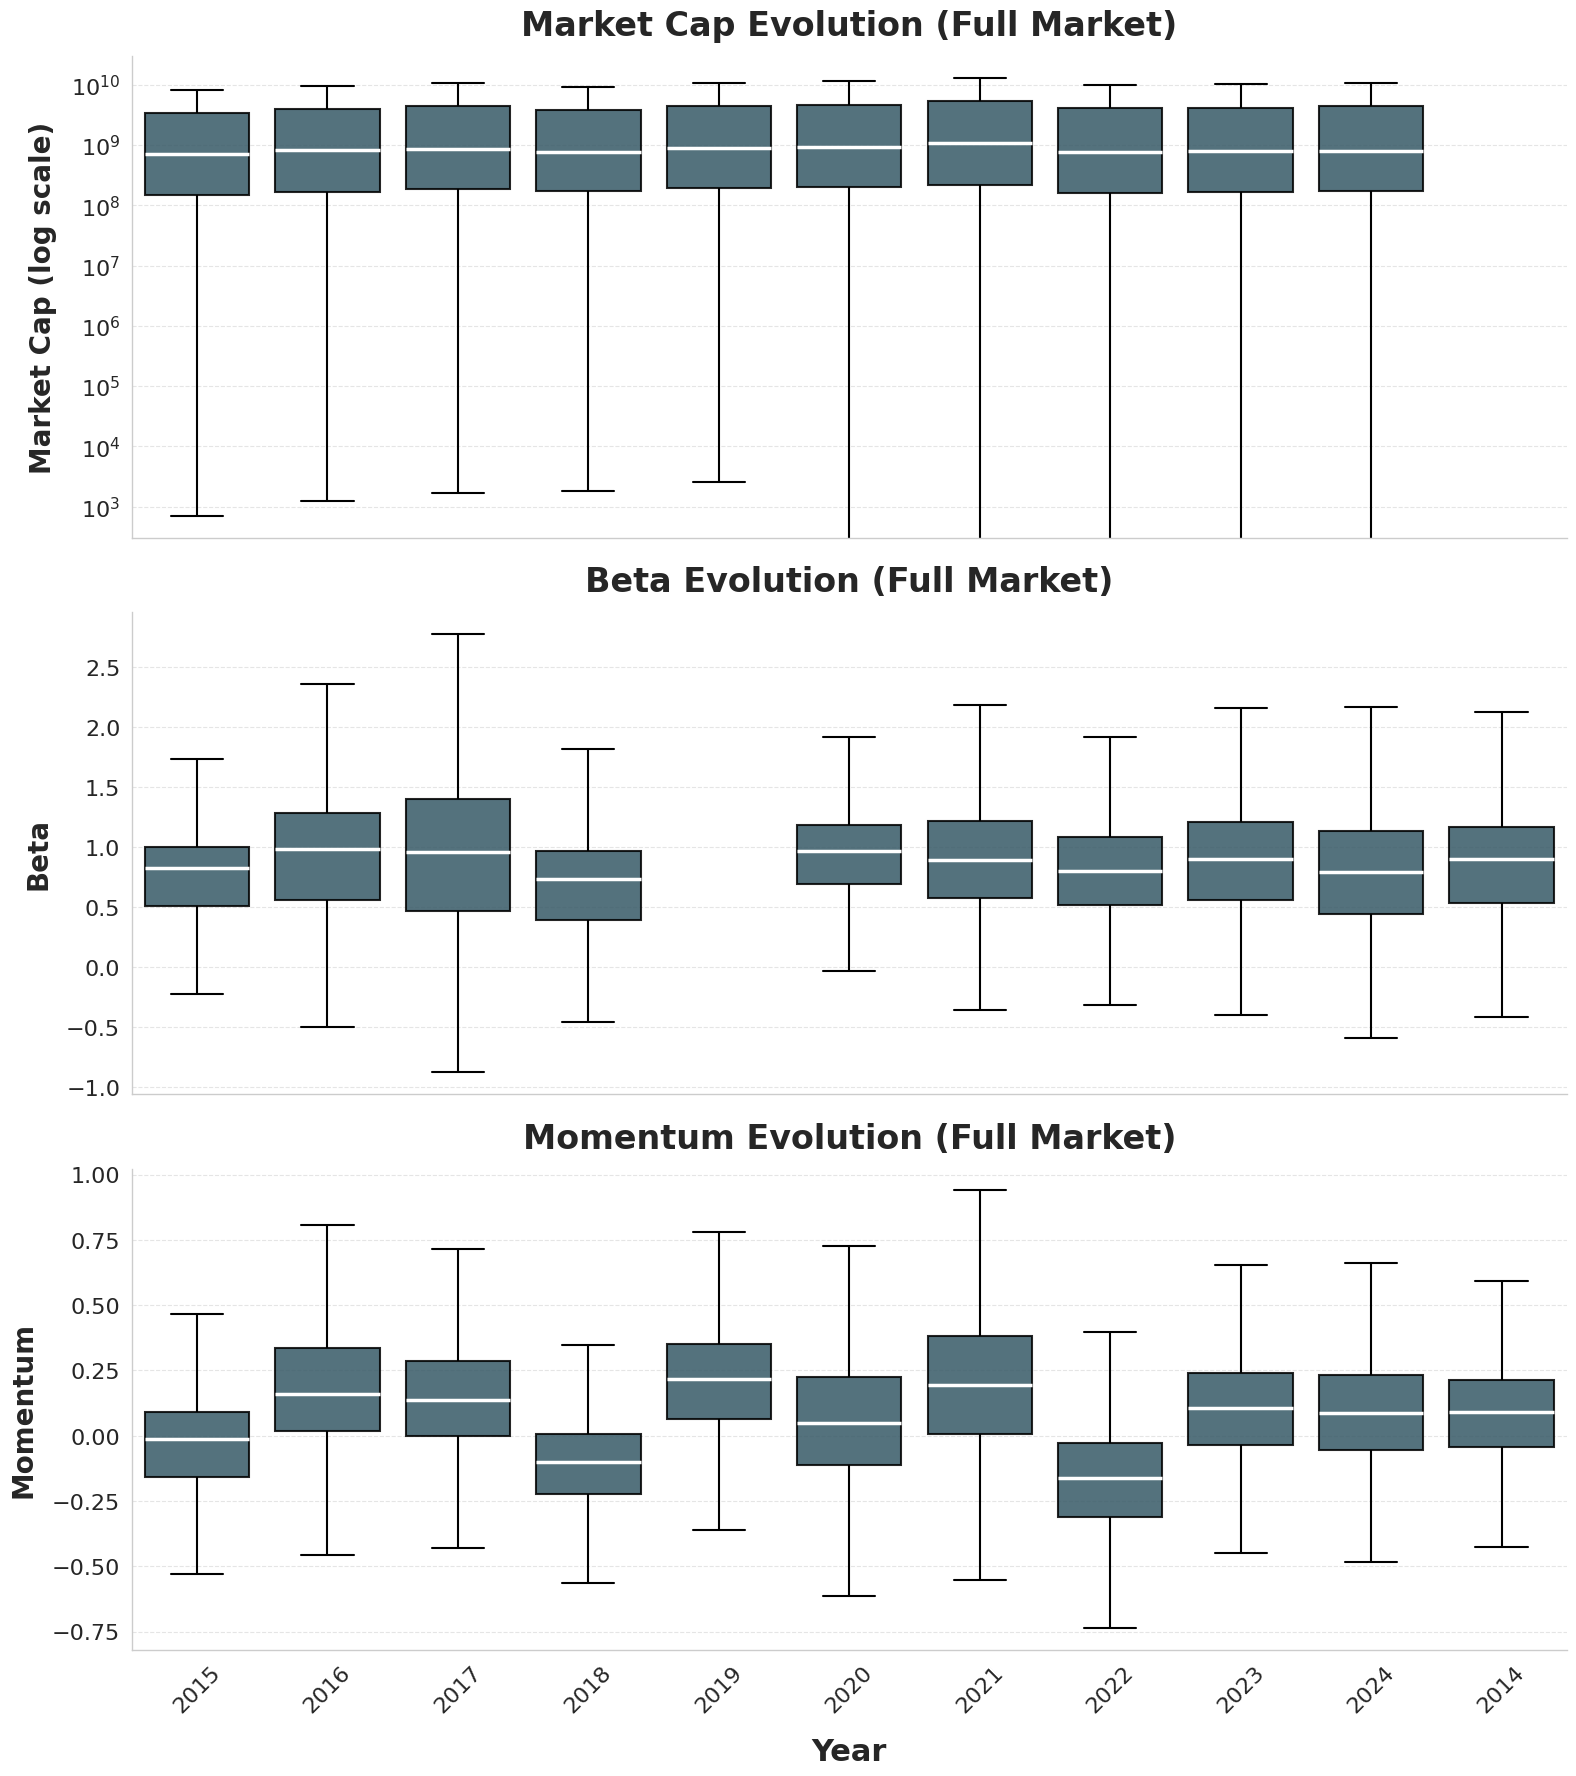

In [4]:
# Mapeamento das métricas
METRICS = {
    "mcap":     {"ylabel": "Market Cap (log scale)", "title": "Market Cap Evolution (Full Market)", "log_scale": True},
    "beta":     {"ylabel": "Beta",                   "title": "Beta Evolution (Full Market)",       "log_scale": False},
    "momentum": {"ylabel": "Momentum",               "title": "Momentum Evolution (Full Market)",   "log_scale": False}
}

records = []
for year in years:
    df_year = df_meta[df_meta['year'] == year]
    
    for metric_prefix in METRICS.keys():
        col_name = f"{metric_prefix}_{year}"
        if col_name in df_year.columns:
            series = df_year[col_name].dropna()
            
            # Tratamento de segurança caso a coluna seja string com vírgula
            if series.dtype == 'object' or series.dtype.name == 'string':
                series = series.astype(str).str.replace(',', '.', regex=False)
                series = pd.to_numeric(series, errors='coerce').dropna()
                
            for val in series.values:
                records.append({
                    "Portfolio": "Full Market",
                    "Year": int(year),
                    "Metric": metric_prefix,
                    "Value": val
                })

df_long = pd.DataFrame(records)

# Preparando o Grid 3x1
fig, axes = plt.subplots(3, 1, figsize=(16, 18), sharex=True)

# Cor neutra para o mercado total
palette = sns.color_palette("colorblind", n_colors=1)

for ax, (metric_prefix, cfg) in zip(axes, METRICS.items()):
    df_metric = df_long[df_long['Metric'] == metric_prefix]
    
    sns.boxplot(
        data=df_metric, 
        x='Year', 
        y='Value', 
        color='#2E5C6E',
        ax=ax,
        showfliers=False,       # Sem outliers extremos para manter a densidade central visível
        linewidth=1.5,
        boxprops=dict(alpha=0.85, edgecolor='black'),
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5)
    )
    
    if cfg['log_scale']:
        ax.set_yscale('log')
        
    ax.set_ylabel(cfg['ylabel'], fontsize=20, fontweight='bold', labelpad=10)
    ax.set_title(cfg['title'], fontsize=24, fontweight='bold', pad=15)
    ax.tick_params(axis='both', which='major', labelsize=16)
    
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xlabel("")

# Eixo X apenas no último painel
axes[-1].set_xlabel("Year", fontsize=22, fontweight='bold', labelpad=15)
axes[-1].set_xticklabels(axes[-1].get_xticklabels(), rotation=45)

sns.despine(fig=fig)
plt.tight_layout()

# Salva figura em qualidade de publicação
fig_path = Path("../../figures")
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / "full_market_mcap_beta_momentum.png", dpi=300, bbox_inches="tight")
plt.show()